In [1]:
import pandas as pd
import glob
import passiogo

USU_CAMPUS_BUS = 3499
# system = passiogo.getSystemFromID(USU_CAMPUS_BUS)

# routes = system.getRoutes()
# display(list(map(lambda route: f"{route.id}: {route.name}", routes)))

# buses = system.getVehicles()
# display(list(map(lambda bus: f"{bus.routeId}: {bus.routeName}", buses)))

# stops = system.getStops()
# named_stops = list(map(lambda stop: (stop.name, (stop.longitude, stop.latitude), list(stop.routesAndPositions.keys())), stops))
# # print(named_stops)
# display(named_stops)

In [25]:
semester = "spring26"
date = "1-16-26"
all_files = glob.glob(f"out/bus/{semester}/bus_{date}_*")

col_names = ["timestamp"] + [f"extra_col_{i}" for i in range(1, 10)]
df_list = (pd.read_csv(f, names=col_names, dtype=str, header=None) for f in all_files)
df = pd.concat(df_list, ignore_index=True)

cols = df.items()
next(cols)

labeled_vehicle_positions = pd.DataFrame(columns=['timestamp', 'vehicle_id', 'route_id', 'coordinates'])

def lat_long_to_tuple(a):
    latitude = a['latitude']
    longitude = a['longitude']

    if latitude == None or longitude == None:
        return None
    else:
        return (float(longitude), float(latitude))

for col_name, col_data in cols:
    vehicle_data = col_data.str.split(pat=r"[\/\@;]", expand=True)
    if len(vehicle_data.columns) != 4:
        continue

    vehicle_data.columns = ['vehicle_id', 'route_id', 'latitude', 'longitude']

    timestamps = df.iloc[:, 0].astype(float)
    timestamps.name = 'timestamp'

    vehicle_data = pd.concat([timestamps, vehicle_data], axis=1)
    vehicle_data.dropna()

    vehicle_data['coordinates'] = vehicle_data[['latitude', 'longitude']].apply(lat_long_to_tuple, axis=1)
    vehicle_data.drop(['latitude', 'longitude'], axis=1, inplace=True)

    labeled_vehicle_positions = pd.concat([labeled_vehicle_positions, vehicle_data])

labeled_vehicle_positions = labeled_vehicle_positions[labeled_vehicle_positions.route_id.isin({'38765', '38768', '53861'})]
labeled_vehicle_positions

,timestamp,vehicle_id,route_id,coordinates
0,1768580793.055483,14327,38768,"(-111.8043683, 41.7460245)"
1,1768580803.361718,14327,38768,"(-111.8043538, 41.74522)"
2,1768580813.673236,14327,38768,"(-111.8043348, 41.7441426)"
3,1768580823.961767,14327,38768,"(-111.8043365, 41.7434311)"
4,1768580834.254659,14327,38768,"(-111.8043431, 41.7432876)"
...,...,...,...,...
2600,1768607606.336741,17703,38765,"(-111.814074, 41.7485506)"
2601,1768607616.63501,17703,38765,"(-111.8140446, 41.7480871)"
2602,1768607626.977659,17703,38765,"(-111.8140795, 41.746987)"
2603,1768607637.278573,17703,38765,"(-111.8141178, 41.746198)"


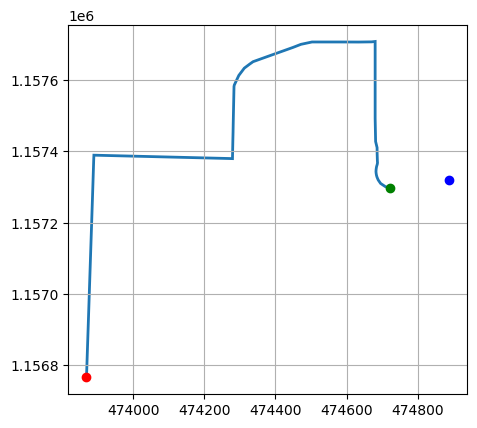

In [26]:
import matplotlib.pyplot as plt
from route import Route
from shapely import Point
import shapely.ops
import shapely.plotting
import pyproj
import usu_routes
import itertools

transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:32142", always_xy=True).transform
usu_stops_transformed = list(map(lambda stop: (stop[0], shapely.ops.transform(transformer, Point(stop[1])), stop[2]), usu_routes.SYSTEM_STOPS))

AT_STOP_THRESHOLD_M = 16

green_line_segments = usu_routes.import_route(usu_routes.GREEN_ROUTE)
green_line = Route(green_line_segments)

ax = plt.gca() 
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
color_pool = itertools.cycle(colors)

for segment in (green_line_segments[i] for i in [4]):
    shapely.plotting.plot_line(segment, color=next(color_pool), linewidth=2, add_points=False)
    start_pt = segment.coords[0]
    end_pt = segment.coords[-1]
    ax.plot(*start_pt, "go", label="Start (project = 0)")
    ax.plot(*end_pt, "ro", label="End (project = length)")

# test_point = Point((-111.8020928, 41.7496328))
test_point = Point((-111.8019188, 41.7495656))
projected_point = shapely.ops.transform(transformer, test_point)
shapely.plotting.plot_points(projected_point, color="blue")

plt.show()

In [27]:
routes = {
    '38765': green_line,
    '38768': None,
    '53861': None
}

def dist_marker(a, prev=None):
    route = routes.get(a['route_id'], None)
    if route == None: return None
    point = Point(a['coordinates'])
    markers = route.distance_markers_for(point)

    # When a route goes back over itself, we disambiguate one of several potential
    # distances by assuming the bus has moved forward the least
    if prev:
        markers = sorted(markers, key=lambda a: a[1] - prev[1] % route.base_distances[-1])

    return markers[0]

def stop_name(a):
    point = Point(a['coordinates'])
    point_transformed = shapely.ops.transform(transformer, point)
    route = a['route_id']
    return next((stop[0] for stop in usu_stops_transformed if route in stop[2] and point_transformed.distance(stop[1]) <= AT_STOP_THRESHOLD_M), "in_transit")

dist_marker(
    {
        'route_id': '38765',
        'coordinates': test_point
    }
)

(2, 1620.2457963822799)

In [28]:
prev_value = None
distances_along_route = []
route_segments = []
stop_names = []
for coordinates, route_id in zip(labeled_vehicle_positions['coordinates'], labeled_vehicle_positions['route_id']):
    a = {
        'coordinates': coordinates,
        'route_id': route_id
    }

    prev_value = dist_marker(a)
    if not prev_value:
        prev_value = (None, None)
    
    route_segments.append(prev_value[0])
    distances_along_route.append(prev_value[1])
    stop_names.append(stop_name(a))

labeled_vehicle_positions["stop"] = stop_names
labeled_vehicle_positions["distance_along_route"] = distances_along_route
# labeled_vehicle_positions["route_segment"] = route_segments # for debugging

# south_campus = labeled_vehicle_positions[labeled_vehicle_positions.route_id.isin({'38768', '53861'})].copy()
# south_campus.drop(columns='route_id', inplace=True)
# south_campus.to_csv(f"data/{semester}/south_campus_{date}.csv", index=False)

housing_express = labeled_vehicle_positions[labeled_vehicle_positions.route_id == '38765'].copy()
housing_express.drop(columns='route_id', inplace=True)
housing_express.to_csv(f"data/{semester}/housing_express_{date}.csv", index=False)